In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [109]:
var=pd.read_csv("C:\\Users\\USER\\OneDrive\\Desktop\\review\\week4\\Amazon_Product_Review.csv")
var.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


Clean review text and ratings

In [110]:
var['reviews.rating']=pd.to_numeric(var['reviews.rating'],errors="coerce")

In [111]:
var=var.dropna(subset=['reviews.rating'])

In [112]:
print(var[['reviews.text','reviews.rating']].head())

                                        reviews.text  reviews.rating
0  I initially had trouble deciding between the p...             5.0
1  Allow me to preface this with a little history...             5.0
2  I am enjoying it so far. Great for reading. Ha...             4.0
3  I bought one of the first Paperwhites and have...             5.0
4  I have to say upfront - I don't like coroporat...             5.0


Average rating by category

In [113]:
avg_rating=var.groupby('categories')['reviews.rating'].mean()
avg_rating

categories
Amazon Devices                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            4.353659
Amazon Devices & Accessories,Amazon Device Accessories,Controllers & Remote Controls,Kindle Store,Amazon Echo Accessories,Remote Controls                                                                                                                                                                                                                                                                                                                                                 

Most reviewed products

In [114]:
top_products=var['name'].value_counts().head(10)
top_products

name
Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker                                        542
Amazon Premium Headphones                                                                     77
Amazon Fire TV                                                                                44
Fire HD 6 Tablet                                                                              38
All-New Amazon Fire 7 Tablet Case (7th Generation                                             27
Kindle Fire HDX 7"                                                                            23
Kindle Paperwhite                                                                             22
Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders     19
All-New Amazon Fire HD 8 Tablet Case (7th Generation                                          18
Replacement Remote for Amazon Fire TV Stick                                                   17
Name: count, dtype: int64

Rating Distribution

In [115]:
var['reviews.rating'].value_counts()

reviews.rating
5.0    741
4.0    236
3.0    124
1.0     42
2.0     34
Name: count, dtype: int64

Perform basic sentiment categorization:
○ Positive
○ Neutral
○ Negative

In [116]:
def sentiment(rating):
    if rating>=4:
        return "Positive"
    elif rating==3:
        return "Neutral"
    else:
        return "Negative"

In [117]:
var["Sentiment"]=var['reviews.rating'].apply(sentiment)
var["Sentiment"].value_counts()

Sentiment
Positive    977
Neutral     124
Negative     76
Name: count, dtype: int64

Detect products with inconsistent ratings.

In [118]:
inconsistent=var.groupby('name')['reviews.rating'].std()
inconsistent.sort_values(ascending=False).head()

name
Moshi Anti-Glare No Bubble Screen Protector for the Fire Phone    1.922751
Certified Refurbished Kindle E-reader - Black                     1.812654
Kindle Oasis with Leather Charging Cover - Black                  1.732051
Replacement Remote for Amazon Fire TV Stick                       1.662740
Alexa Voice Remote for Amazon Echo and Echo Dot                   1.618347
Name: reviews.rating, dtype: float64

Compare verified vs non-verified reviews if available.

Histogram → Rating distribution

Text(0, 0.5, 'Count')

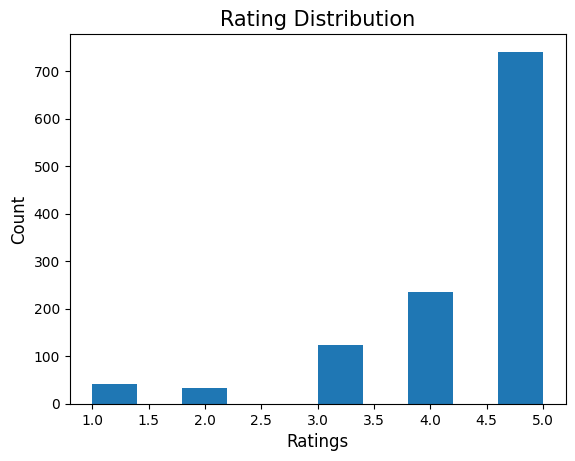

In [119]:
plt.hist(var['reviews.rating'])
plt.title("Rating Distribution",fontsize=15)
plt.xlabel("Ratings",fontsize=12)
plt.ylabel("Count",fontsize=12)

Bar Plot → Top reviewed products

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Amazon Tap - Alexa-Enabled Portable Bluetooth Speaker'),
  Text(1, 0, 'Amazon Premium Headphones'),
  Text(2, 0, 'Amazon Fire TV'),
  Text(3, 0, 'Fire HD 6 Tablet'),
  Text(4, 0, 'All-New Amazon Fire 7 Tablet Case (7th Generation'),
  Text(5, 0, 'Kindle Fire HDX 7"'),
  Text(6, 0, 'Kindle Paperwhite'),
  Text(7, 0, 'Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders'),
  Text(8, 0, 'All-New Amazon Fire HD 8 Tablet Case (7th Generation'),
  Text(9, 0, 'Replacement Remote for Amazon Fire TV Stick')])

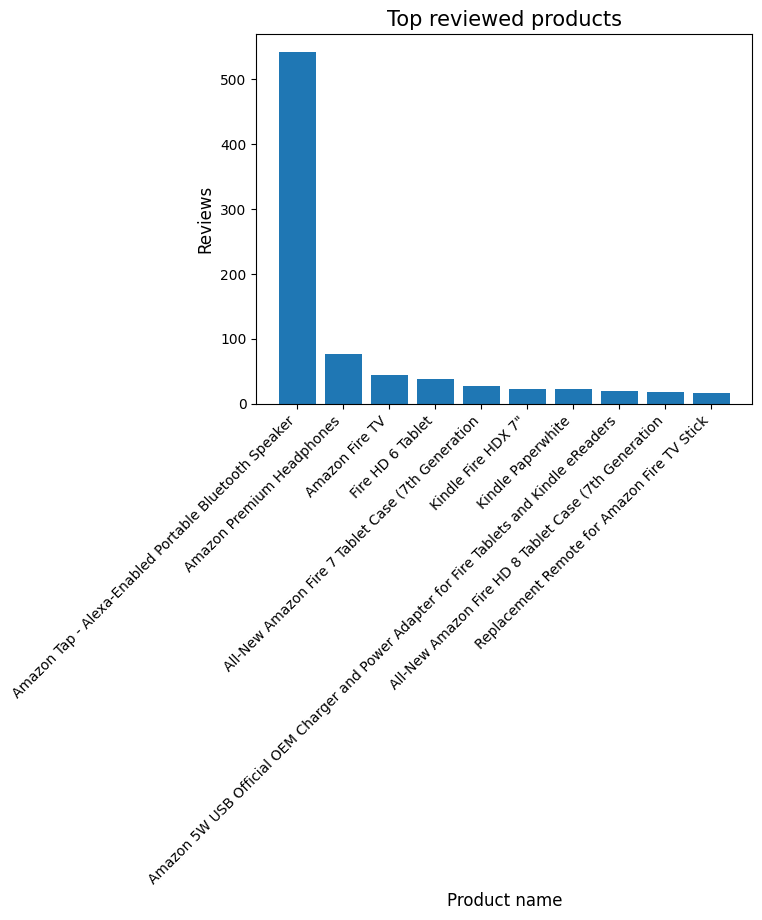

In [120]:
top_products=var['name'].value_counts().head(10)
plt.bar(top_products.index,top_products.values)
plt.title("Top reviewed products",fontsize=15)
plt.xlabel("Product name",fontsize=12)
plt.ylabel("Reviews",fontsize=12)
plt.xticks(rotation=45,ha='right')

Heatmap → Review correlations

Text(0.5, 1.0, 'Correlation Heatmap')

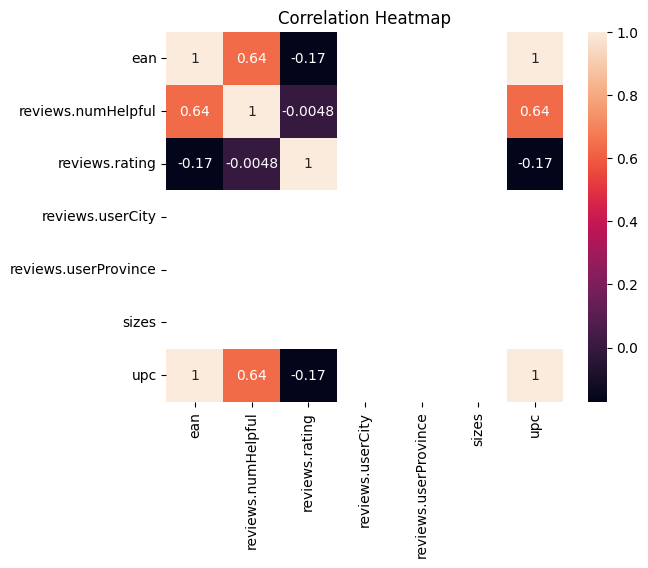

In [121]:
sns.heatmap(var.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap")